### **A rendre le 11 Mars avant 23h:59mn sur Chamilo dans "Travaux".**
##### ***N'oubliez pas de preciser vos Nom et Prenom comme nom du ficher notebook***

Support théorique: 
* tp1.pdf partie 1 lissage linéaire depuis https://chamilo.grenoble-inp.fr/
* Cours2-TI-filtrage-2019.pdf depuis https://chamilo.grenoble-inp.fr/

Un système d’enregistrement d’image ne restitue pas l’image de manière parfaite : des informations
parasites apparaissent et viennent s’ajouter de manière aléatoire aux éléments de la scène d’origine.
Cet effet est désigné sous le terme général de ”bruit”. La chaine d’acquisition classique comporte donc le phénomène physique (faisceau lumineux, les rayons X au autres), le capteur transformant le phénomène physique en signal électrique, l’amplification du signal et la conversion analogique/numérique.

Les principales sources de bruit sont les suivantes :
*   le bruit lié au phénomène physique mesuré
*   le bruit lié au capteur
*   le bruit lié à l’électronique d’acquisition
*   le bruit lié à la quantification



#### Question 1: Quels sont les objectifs du lissage?

Réponse: ....

# Lissage Linéaire

Cette catégorie de filtres correspond à des filtres passe-bas, éliminant les hautes fréquences qui représentent généralement le bruit. Le problème est de déterminer la fréquence de coupure exacte du filtre car les contours des objets sont eux aussi représentés par des fréquences relativement élevées, qu’il faut conserver.
Le rôle d’un filtre de lissage peut être résumé en quatre actions :
* Tous les pixels d’une zone relativement homogène doivent être à une même valeur : cela revient àréduire la variance de cette zone homogène.
* Tous les pixels proches d’un contour doivent appartenir à une zone homogène s’ils n’appartiennent pas à ce contour. Cela revient à ne pas créer de nouvelles zones ou valeurs à proximité des points de contours.
* Aucun point de contour ne doit disparaître : le filtre ne doit pas entraîner de perte de résolution sur l’image, en particulier sur les zones où les contours ont 1 ou 2 pixels d’épaisseurs (Images de caractères ou d’empreintes digitales par exemple).
* Le filtre ne doit pas entraîner de déformations de ces contours (en particulier pour les coins et les intersections de contours) et ne doit pas déplacer ces contours (en particulier lorsque des mesures métriques sont envisagées).



### Question 2: Quel est l'inconvénient principal du filtre linéaire?

Réponse: ....

## **1. FFT, Filtrage Gaussien par FFT:**

### Question 3: Quel est l'intéret de la transformée de Fourier pour le filtrage?

Réponse: ...

### Question 4: Citer 3 propriétés du produit de convolution.

Réponse:...

### Question 5 : Implémentez dans le domaine discret la transformée de Fourier de la gaussienne 2D, exprimée par $\text{TF}(G(u, v))$ ci-dessous. Visualisez l'amplitude du résultat en échelle logarithmique.

$$\text{TF}(G(u, v)) = \exp\left( -2\pi^2 \sigma^2 \left( \left(\frac{u - N/2}{N}\right)^2 + \left(\frac{v - M/2}{M}\right)^2 \right) \right)$$
$$\quad \text{avec} \quad 0 \leq u < N \quad \text{et} \quad 0 \leq v < M$$

### **Remarque 1:** attention, ici $\text{TF}(G(u, v))$ est centrée sur le milieu de l’image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
def gaussian_2d_fourier(N, M, sigma):
    # Créer une grille de taille N, M
    n = np.arange(N)
    m = np.arange(M)  
    
    n_coord, m_coord = np.meshgrid(n, m)
    
    # Appliquer la formule
    tf_gaussian = np.exp(-2 * np.pi**2 * sigma**2 * ((((n_coord-(N//2)) / N)**2 + ((m_coord-(M//2))/ M)**2)))
    
    return tf_gaussian

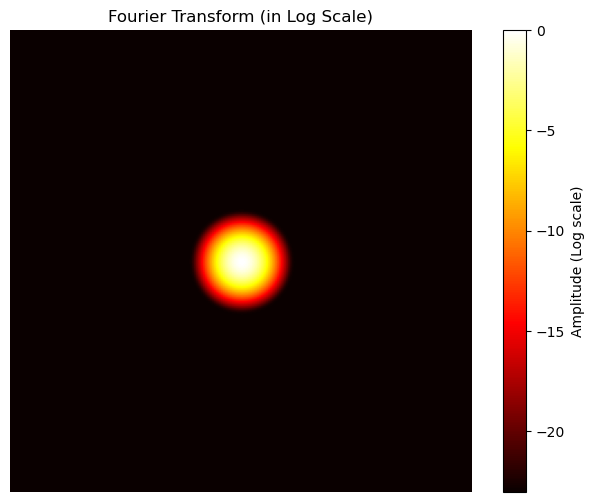

In [3]:
N, M = 256, 256 
sigma = 10

# Calcul de la transformée de Fourier de la gaussienne
tf_gaussian = gaussian_2d_fourier(N, M, sigma)

# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(np.log(np.abs(tf_gaussian) + 1e-10), cmap='hot', extent=[0, N, 0, M])
plt.title('Fourier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

### Question 6: 
* ### Visualisez l'image mandrill256.pgm. 
* ### Calculer sa transformée de Fourier en utilisant la fonction numpy np.fft.fft2(image) puis visualiser le résultat.
* ### Visualisez np.fft.fftshift(np.fft.fft2(image)). Que fait np.fft.fftshift ? Quelle propriété de la transformée de Fourier est utilisée ? Pourquoi fait-on cela ?

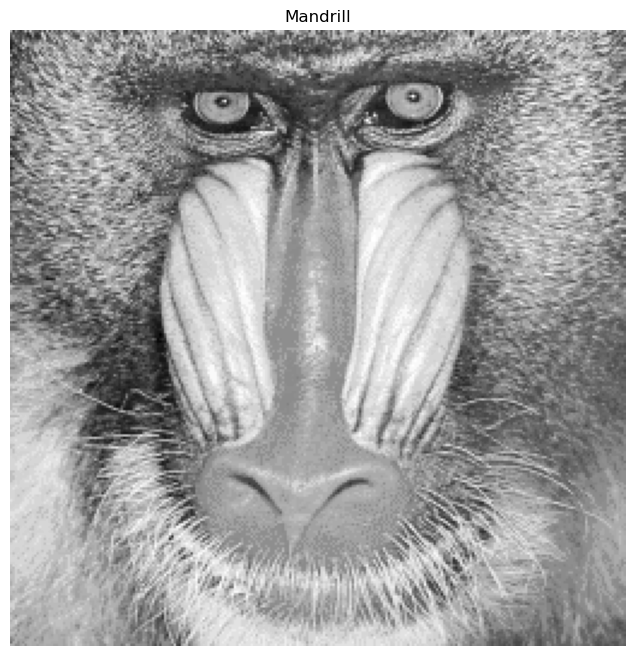

In [4]:
mandrill = io.imread('./imagestp/mandrill256.pgm')
plt.figure(figsize=(8, 8))
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill')
plt.axis('off') 
plt.show()

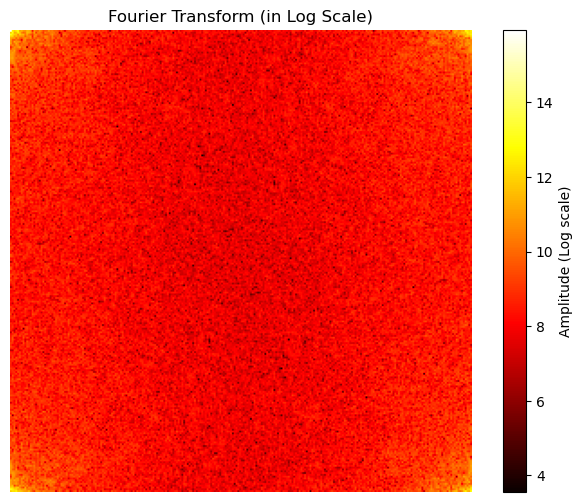

In [5]:
# Calcul de la transformée de Fourier
tf_mandrill = np.fft.fft2(mandrill)

# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(np.log(np.abs(tf_mandrill) + 1e-10), cmap='hot')
plt.title('Fourier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

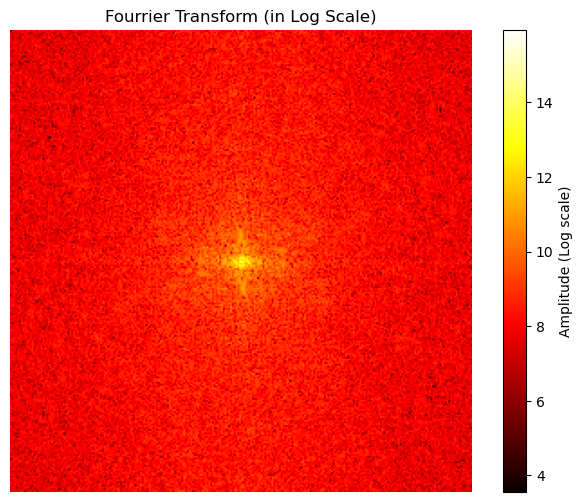

In [6]:
# Calcul de la transformée de Fourier

tf_mandrill_shifted =  np.fft.fftshift(np.fft.fft2(mandrill))

# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(np.log(np.abs(tf_mandrill_shifted) + 1e-10), cmap='hot')
plt.title('Fourrier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

### Question 7: 
* ### Utilisez la transformation de Fourier rapide (FFT) pour appliquer le filtre gaussien dans le domaine fréquentiel.
* ### Visualisez le résultat sur mandrill256.pgm.

In [7]:
def frequency_gaussian_filter(image, sigma):
    
    N, M = image.shape
    
    freq_image = np.fft.fft2(image)
    
    freq_image_shifted = np.fft.fftshift(freq_image)
    
    gaussian_filter = gaussian_2d_fourier(N, M, sigma)
    
    filtered_freq_image_shifted = freq_image_shifted * gaussian_filter
    
    filtered_freq_image = np.fft.ifftshift(filtered_freq_image_shifted)
    
    filtered_image = np.fft.ifft2(filtered_freq_image)

    return np.abs(filtered_image), gaussian_filter

In [8]:
# Load the image using skimage
mandrill = io.imread('./imagestp/mandrill256.pgm')
sigma = 4
filtered_mandrill, gaussian_filter_on_mandrill = frequency_gaussian_filter(mandrill, sigma = sigma)

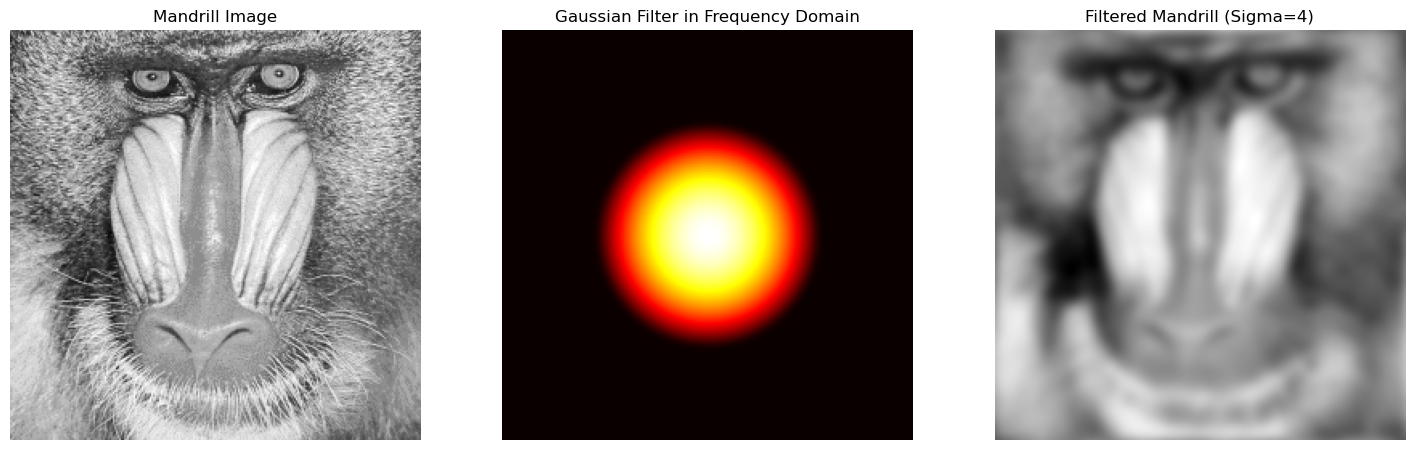

In [9]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(np.abs(gaussian_filter_on_mandrill) + 1e-10), cmap='hot')  # Log scale for visibility
plt.title('Gaussian Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma})')
plt.axis('off')

plt.show()


### Question 9: On souhaite corrompre l'image mandrill256.pgm. 
* ### Implémentez une fonction qui rajoute un bruit gaussien (moyenne 0, écart-type std) à une image. 
* ### Testez et visualisez sur mandrill256.pgm (std = 50).

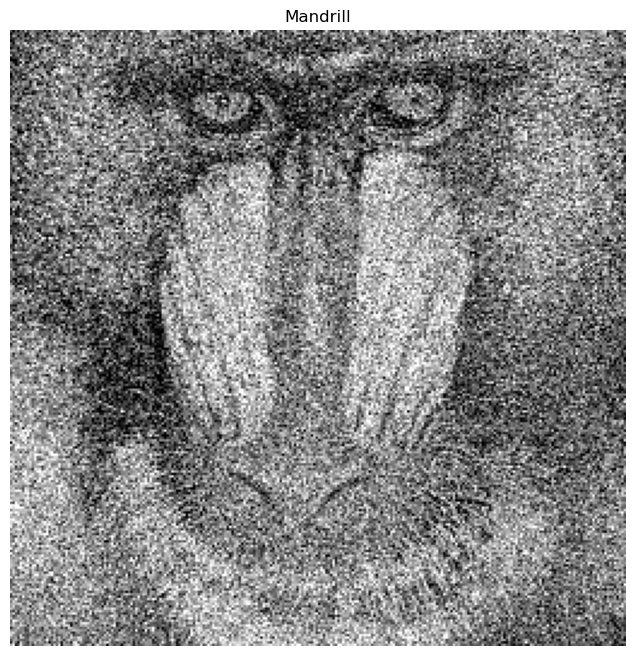

In [10]:
def add_white_noise(image, mean=0, std=10):
    
    noise = np.random.normal(mean, std, image.shape)
    
    noisy_image = image + noise
    
    noisy_image = np.clip(noisy_image, 0, 255)
    
    return noisy_image


noisy_mandrill = add_white_noise(mandrill, mean=0, std=50)

plt.figure(figsize=(8, 8))
plt.imshow(noisy_mandrill, cmap='gray')
plt.title('Mandrill')
plt.axis('off') 
plt.show()


### Question 8: Nous souhaitons étudier l'effet du paramètre sigma. Tracez la courbe PSNR entre mandrill256.pgm et le résultat de l'application du filtre gaussien FFT sur sa version corrompue en fonction de plusieurs valeurs de sigma du filtre (par exemple, des valeurs entre 0.1 et 10). Que remarquez-vous ?

* ### Pour rappel Si l’image non bruitée est connue, une mesure de comparaison est le Peak Signal Noise Ratio (PSNR) basé sur l’erreur quadratique entre l’image non bruitée connue que l’on cherche et l’image lissée qui approxime cette image. Plus l’image lissée ressemble à l’image recherchée, plus le PSNR est grand. Le PSNR est donné par : 

$$
\text{PSNR}(im_1, im_2) = 10 \log_{10} \left( \frac{(P_{\text{max}})^2}{\text{MSE}} \right)
$$

* ### où l'**erreur quadratique moyenne (MSE)** est définie par :

$$
\text{MSE} = \frac{1}{N \times M} \sum_{i=0}^{N-1} \sum_{j=0}^{M-1} \left(im_1(i, j) - im_2(i, j)\right)^2
$$

* ### où $P_{\text{max}}$ est la valeur maximale d'un pixel, 255 dans notre cas.

In [11]:
def calculate_psnr(im1, im2, pmax=255.0):    
    mse = np.mean((im1 - im2) ** 2)
    
    if mse == 0:
        return 100
        
    psnr = 10 * np.log10((pmax ** 2) / mse)
    
    return psnr

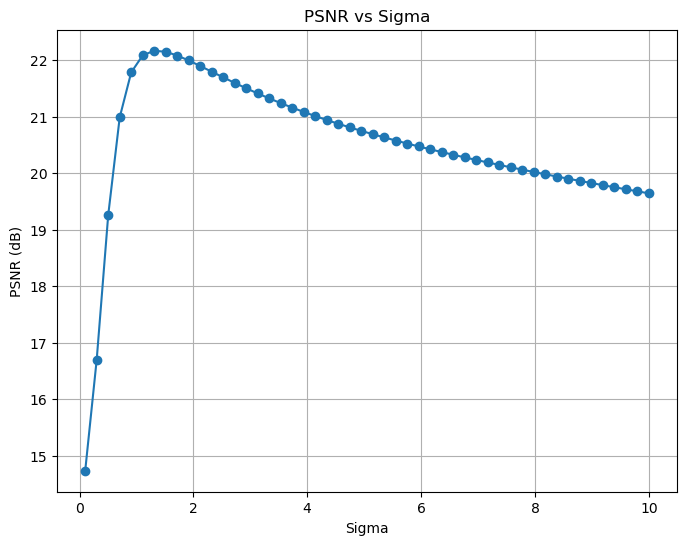

In [12]:
sigmas = np.linspace(0.1, 10, 50)
psnrs = []

for sigma in sigmas:
    filtered_mandrill ,_ = frequency_gaussian_filter(noisy_mandrill, sigma = sigma)
    psnr = calculate_psnr(mandrill, filtered_mandrill)
    psnrs.append(psnr)

plt.figure(figsize=(8, 6))
plt.plot(sigmas, psnrs, marker='o')
plt.title('PSNR vs Sigma')
plt.xlabel('Sigma')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()


### Question 9: On vous donne dans imagestp/ImagesSynthetiques.zip des images synthétiques construites à partir d’une image parfaite (formes2.pgm), qui subit un filtrage passe bas (formes2g.pgm) à laquelle on ajoute ensuite un bruit de type :
    -  gaussien de moyenne nulle et de variance i pour les images formes2bbi.pgm (1 seule réalisation par variance)
    -  poissonien pour les images formes2pi.pgm (plusieurs réalisations différentes)
    -  poivre et sel pour les images formes2spi.pgm, avec des densité de pixels défectueux différentes
    -  peckle, pour les images formes2pi.pgm (bruit multiplicatif dont le coefficient est de distribution gausienne nulle et de variance i)

* ### Appliquez le filtre gaussian sur ces images. Comparer qualitativement (i.e. observations visuelle) les résultats obtenus pour les différents types de bruit (gaussien, poisson, speeckle, poivre et sel).
* ### Pour quel type de bruit le filtre gaussien est-il efficace ?

### Question 10: Creation d'une image hybride. Nous souhaitons implementer ces filtres dans le domaine spectrale:

* ### Filtre passe bas:
$$H(u, v) =
\begin{cases}
1 & \text{if } \sqrt{(u - N/2)^2 + (v - M/2)^2} \leq r \\
0 & \text{otherwise}
\end{cases}$$

* ### Filtre pass haut:
$$
H(u, v) =
\begin{cases}
0 & \text{if } \sqrt{(u - N/2)^2 + (v - M/2)^2} \leq r \\
1 & \text{otherwise}
\end{cases}
$$


### Question 10.1: Implémentez une fonction filtre passe-bas dans le domaine fréquentiel. Testez et visualisez sur monroe.pgm

In [13]:
def dist_center_fct(N, M):
    """
    cette fonction est la fonction racine avec la racine carré dans la fonction H 
    pour calculer la distance
    """
    n = np.arange(N)
    m = np.arange(M)  
    
    n_coord, m_coord = np.meshgrid(n, m,  indexing='ij')
    circle = np.sqrt((n_coord - N//2)**2 + (m_coord - M//2)**2)
    return circle

In [14]:
def filtre_passe_bas(image, radius):
    N, M = image.shape
    
    freq_image = np.fft.fft2(image)
    
    freq_image_shifted = np.fft.fftshift(freq_image)
    
    dist_center = dist_center_fct(N, M)
    filter_LP = np.zeros_like(dist_center)
    filter_LP[dist_center <= radius] = 1
    
    filtered_freq_image_shifted = freq_image_shifted * filter_LP
    
    filtered_freq_image = np.fft.ifftshift(filtered_freq_image_shifted)
    
    filtered_image = np.fft.ifft2(filtered_freq_image)

    return np.abs(filtered_image), filter_LP

In [15]:
monore =  io.imread('./imagestp/monroe.pgm')
monore_filtered, low_pass_filter = filtre_passe_bas(monore, radius=20)

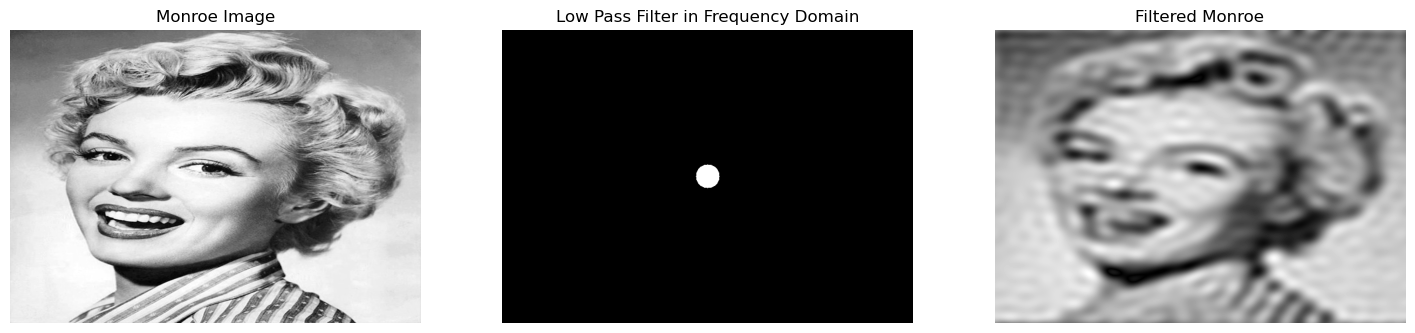

In [16]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(monore, cmap='gray')
plt.title('Monroe Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(low_pass_filter, cmap='gray')  # Log scale for visibility
plt.title('Low Pass Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(monore_filtered, cmap='gray')
plt.title(f'Filtered Monroe')
plt.axis('off')

plt.show()

### Question 10.2: Implémentez une fonction filtre passe-haut dans le domaine fréquentiel. Testez et visualisez sur einstein.pgm

In [17]:
def filtre_passe_haut(image, radius):
    N, M = image.shape
    
    freq_image = np.fft.fft2(image)
    
    freq_image_shifted = np.fft.fftshift(freq_image)
    
    dist_center = dist_center_fct(N, M)
    filter_LP = np.ones_like(dist_center)
    filter_LP[dist_center <= radius] = 0
    
    filtered_freq_image_shifted = freq_image_shifted * filter_LP
    
    filtered_freq_image = np.fft.ifftshift(filtered_freq_image_shifted)
    
    filtered_image = np.fft.ifft2(filtered_freq_image)

    return np.abs(filtered_image), filter_LP

In [18]:
einstein =  io.imread('./imagestp/einstein.pgm')
einstein_filtered, high_pass_filter = filtre_passe_haut(einstein, radius=3)

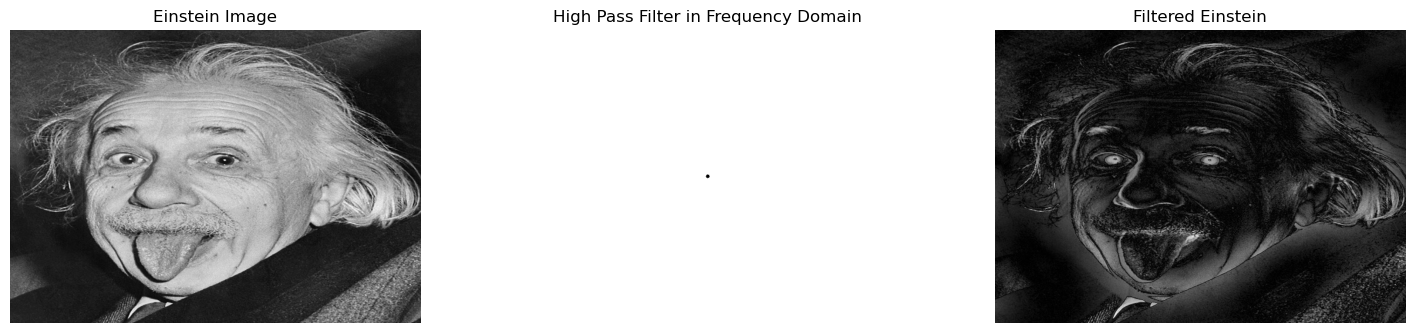

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(einstein, cmap='gray')
plt.title('Einstein Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(high_pass_filter, cmap='gray')  # Log scale for visibility
plt.title('High Pass Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(einstein_filtered, cmap='gray')
plt.title(f'Filtered Einstein')
plt.axis('off')

plt.show()

### Question 10.3: Moyennez les deux images filtrées. Regardez de loin, puis de près, et concluez.

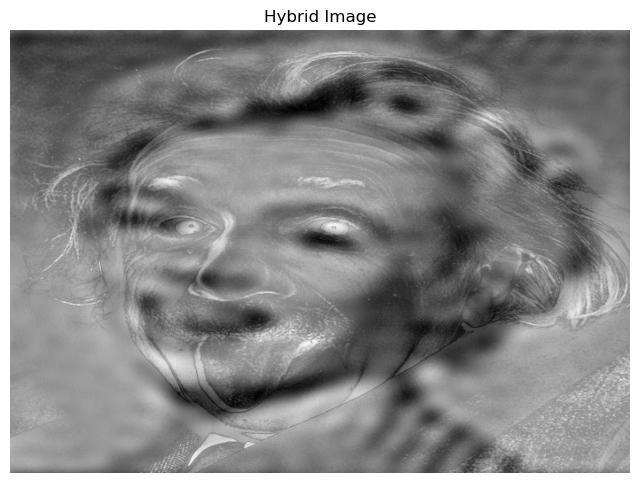

In [20]:
hybrid_image = (einstein_filtered + monore_filtered)/2
plt.figure(figsize=(8, 8))
plt.imshow(hybrid_image, cmap='gray')
plt.title('Hybrid Image')
plt.axis('off') 
plt.show()

## **2. Convolution Spatiale:**


### Dans le domaine discret, une convolution entre une image $I$ et un filtre $G$ est définie par :

$$R(x, y) = \sum_{i=-n}^{n} \sum_{j=-m}^{m} I(x + i, y + j) \cdot G(i, j)$$


### **Remarque 2, problèmes des bords :** dans le domaine numérique, l'image est de taille finie. La convolution des pixels aux bords de l'image fait appel à des pixels situés en dehors de l'image. Ces pixels peuvent prendre les valeurs suivantes :
* ### Zéro.
* ### La valeur du pixels du bord : on prolonge l’image par continuité.
* ### La valeur des pixels du bord opposé de l’image : on périodise l’image. C’est cette version qui sera utilisée ici pour permettre une comparaison avec le lissage par FFT qui périodise l’image par définition. Vous pourrez utiliser numpy.pad avec le mode='wrap'.

### Question 11: Implémentez un filtre de convolution gaussien de taille n (n=m), et d'écart type sigma. Visualisez pour un choix de n et de sigma.

In [21]:
def gaussian_kernel(n, sigma):
    size = 2*n + 1
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    
    
    return kernel / np.sum(kernel)

In [22]:
sigma = 6
n = 4
kernel = gaussian_kernel(n, sigma)

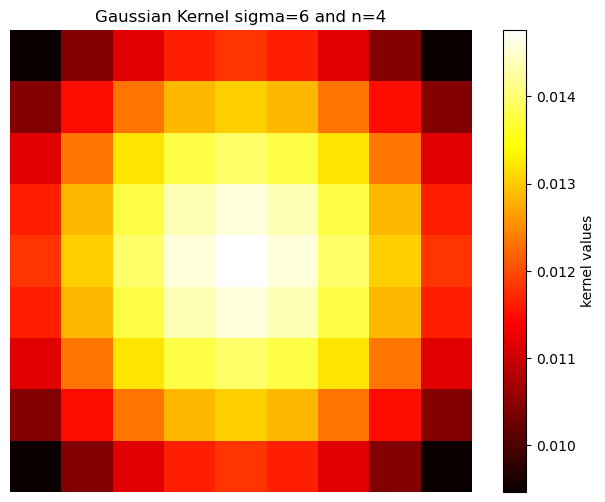

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(kernel, cmap='hot')
plt.title(f'Gaussian Kernel sigma={sigma} and n={n}')
plt.colorbar(label='kernel values')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

### Question 12: Appliquez ce filtre de convolution sur mandrill256.pgm et visualisez le résultat.

In [24]:
def apply_filter(image, kernel):
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='wrap')

    filtered_image = np.zeros_like(image)

    for i in range(img_height):
        for j in range(img_width):
            region = padded_image[i:i + kernel_height, j:j + kernel_width]
            value = 0.0
            filtered_image[i, j] = np.sum(region * kernel)

    filtered_image = np.clip(filtered_image, 0, 255)

    return filtered_image

In [25]:
filtered_mandrill_spatial_2d = apply_filter(mandrill, kernel)

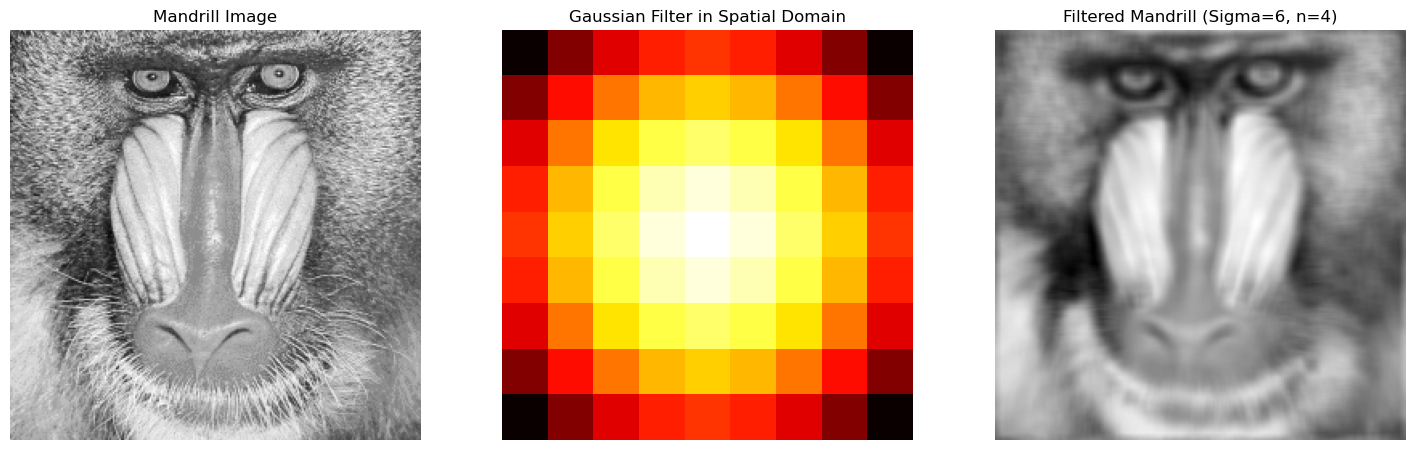

In [26]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel, cmap='hot')  # Log scale for visibility
plt.title('Gaussian Filter in Spatial Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill_spatial_2d, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma}, n={n})')
plt.axis('off')

plt.show()

### Question 14: Le filtre gaussien dans le domaine spatial est une fonction qui suit une loi gaussienne bidimensionnelle, laquelle peut être factorisée en un produit de deux fonctions gaussiennes unidimensionnelles. Cela permet de séparer la convolution 2D en deux convolutions 1D successives. 

* ### Implémentez et visualisez un filtre gaussien 1D. Implémentez un filtre spatial gaussien en utilisant deux convolutions 1D successives. Visualisez le résultat sur mandrill256.pgm. 
* ### Quel est l'avantage d'utiliser deux filtres 1D successifs plutôt qu'un filtre 2D ?

In [27]:
def gaussian_kernel_1d(n, sigma):
    size = 2*n + 1
    x = np.linspace(-(size // 2), size // 2, size)
    kernel = np.exp(-x**2 / (2*sigma**2))
    kernel /= np.sum(kernel) 
    return kernel[:, None]

In [28]:
sigma = 6
n = 4
kernel_1d = gaussian_kernel_1d(n, sigma)

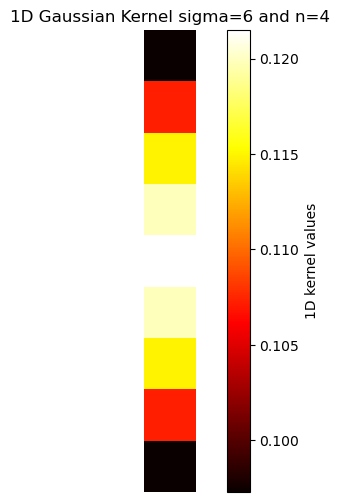

In [29]:
plt.figure(figsize=(8, 6))
plt.imshow(kernel_1d, cmap='hot')
plt.title(f'1D Gaussian Kernel sigma={sigma} and n={n}')
plt.colorbar(label='1D kernel values')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

In [30]:
def apply_1d_row_cols(image, kernel):
    image = apply_filter(image, kernel)
    image = apply_filter(image, kernel.T)
    return image

In [31]:
filtered_mandrill_spatial_1d = apply_1d_row_cols(mandrill, kernel_1d)

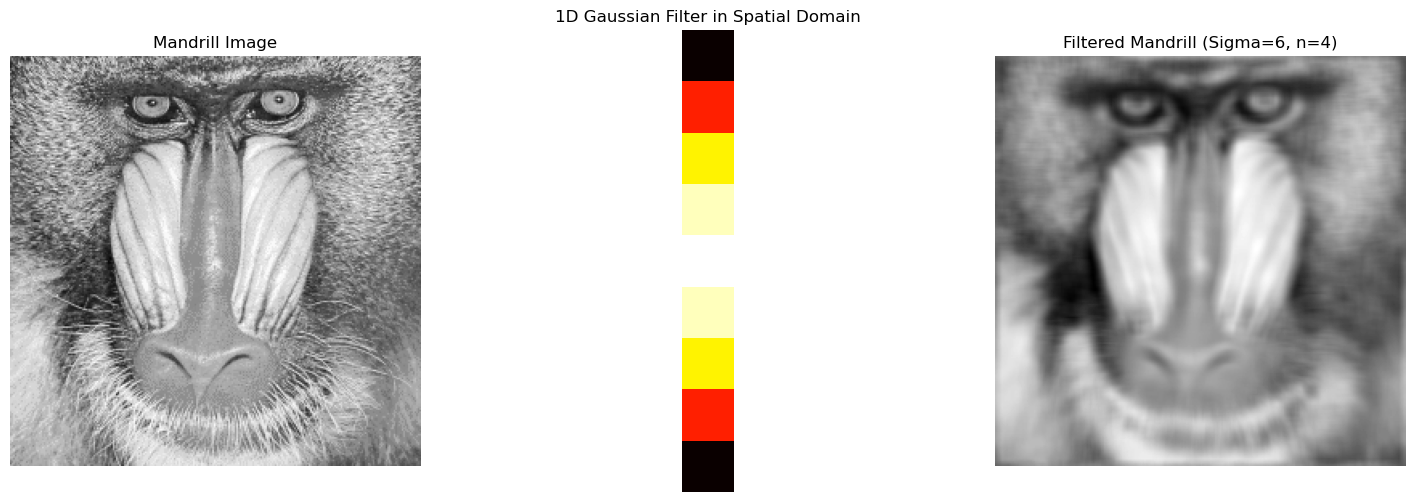

In [32]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel_1d, cmap='hot')  # Log scale for visibility
plt.title('1D Gaussian Filter in Spatial Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill_spatial_1d, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma}, n={n})')
plt.axis('off')

plt.show()

### Question 13: 
* ### Tracez l’erreur quadratique moyenne (MSE) entre le résultat du filtrage gaussien par FFT et le résultat d'un filtrage gaussien spatial en fonction de la taille du noyau de filtrage, par exemple, n allant de 1 à  6*sigma (pour des valeurs fixées de sigma = 1, 5, 10) pour les images formes2g.pgm et radio1024.pgm. Commenter les résultats.
* ### Déterminer approximativement la taille du filtre spatial $n = W(\sigma)$ (qui depend de $\sigma$) pour lequel les résultats sont similaires entre le filtrage fréquentiel par FFT et le filtrage spatial ?


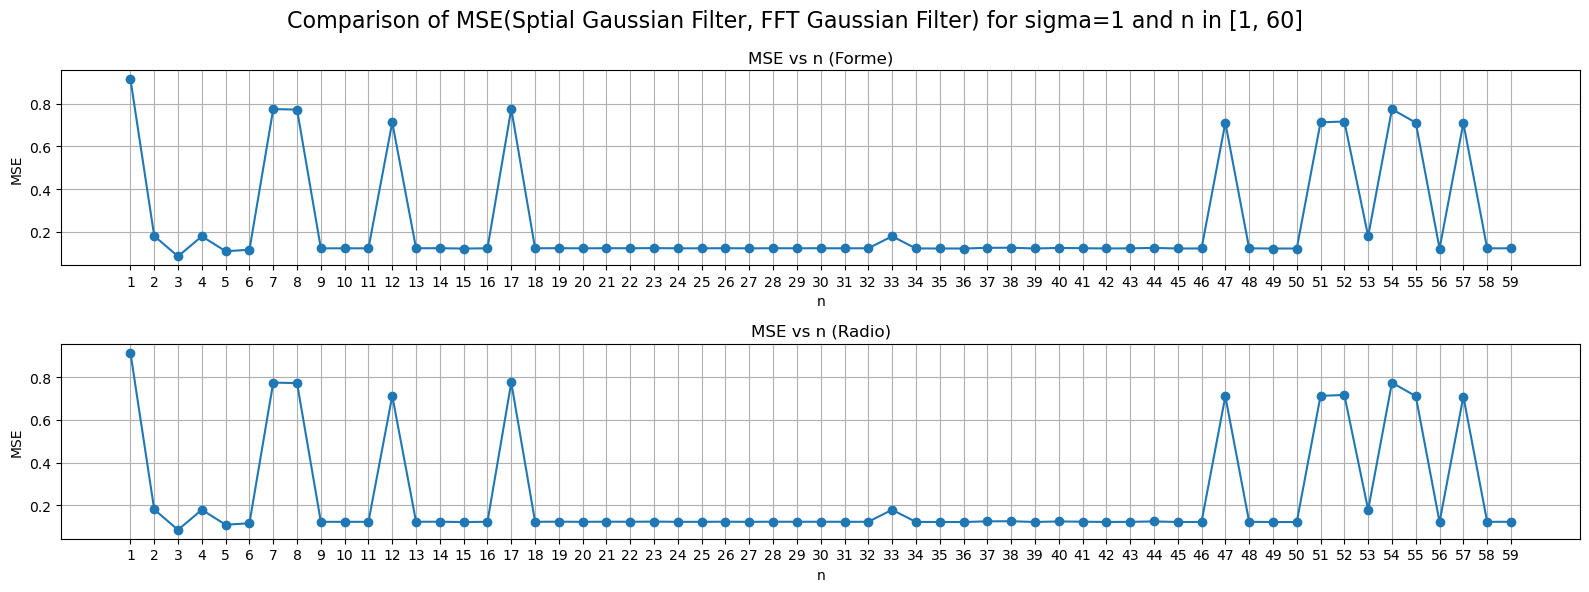

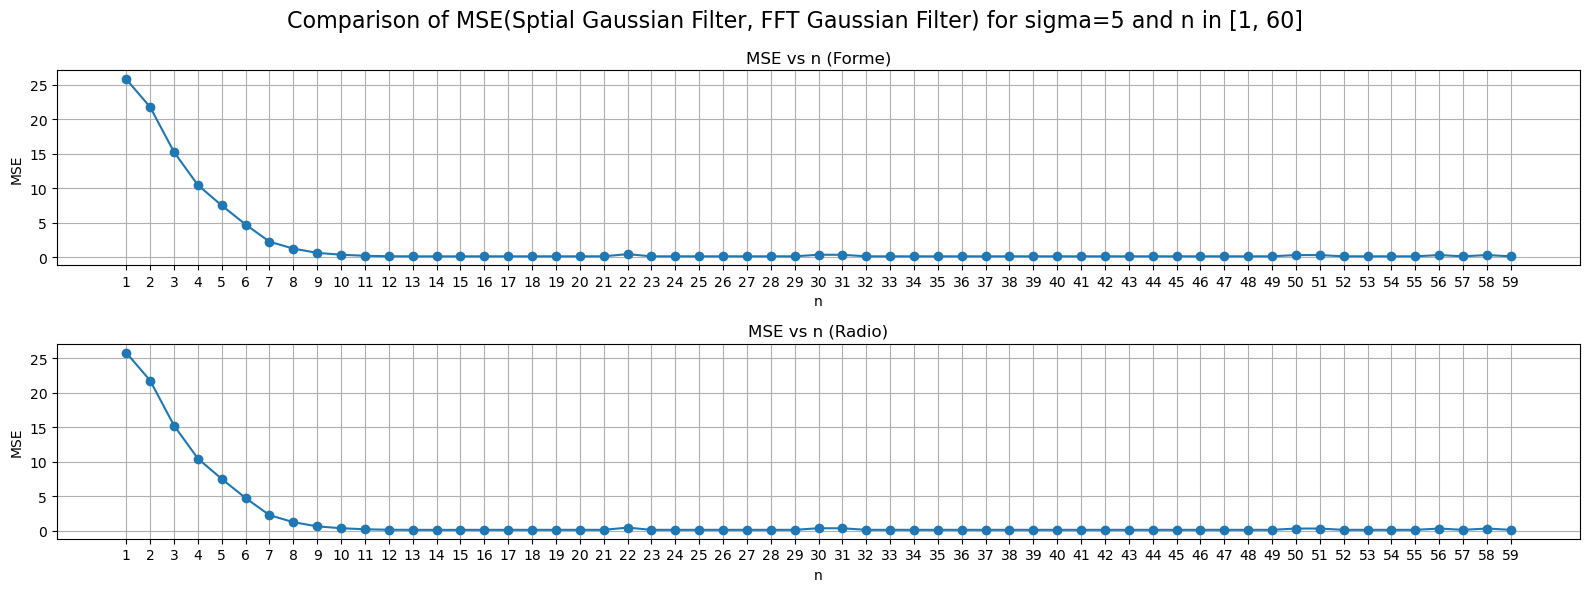

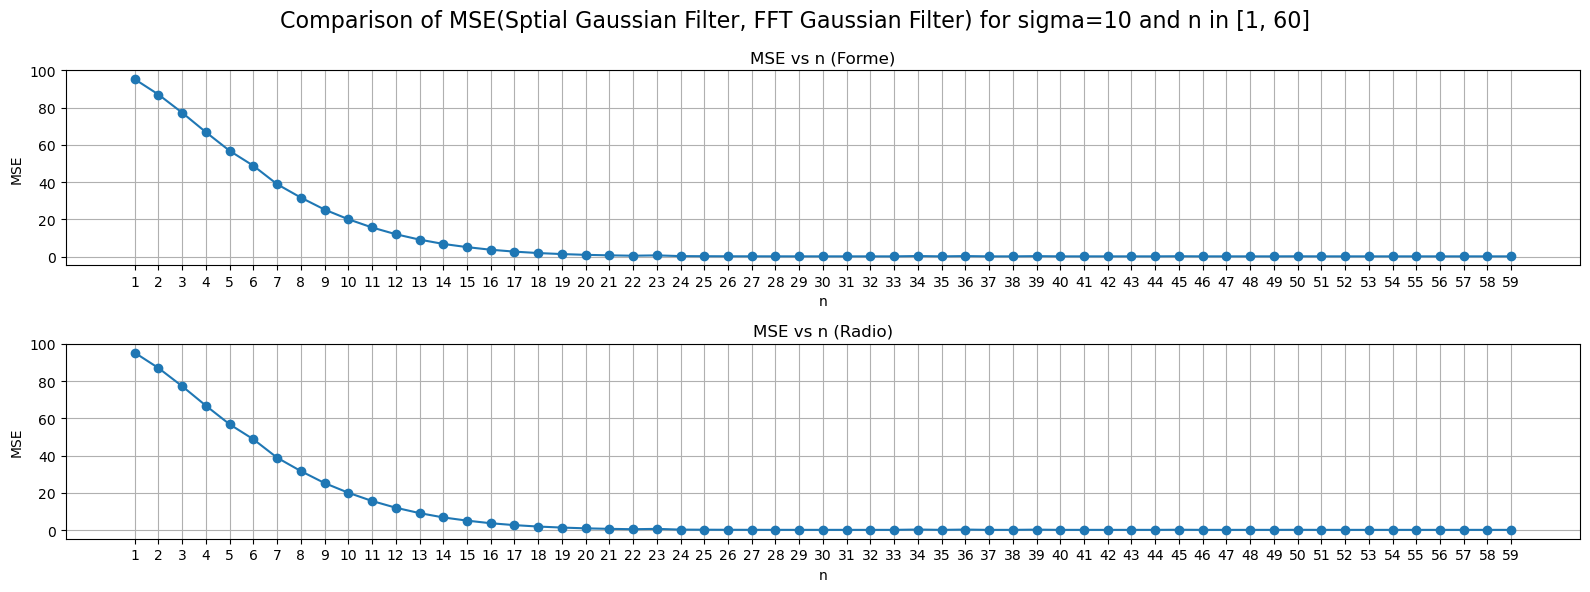

In [33]:
# Charger les images
image_1 = io.imread('./imagestp/Archive/formes2g.pgm')
image_2 = io.imread('./imagestp/radio1024.pgm')

# Définir les valeurs de sigma et les tailles de masque à tester
sigma_values = [1, 5, 10]
Ns = list(range(1, 6*10))
for sigma in sigma_values:
    eqm_results_formes = []
    eqm_results_radio = []

    image_1_filtered,_ = frequency_gaussian_filter(image_1, sigma = sigma)
    image_2_filtered,_ = frequency_gaussian_filter(image_1, sigma = sigma)
    
    for n in Ns:
        
        eqm_results_formes.append(np.mean((image_1_filtered - apply_filter(image_1, gaussian_kernel(n, sigma)))**2))
        #eqm_results_radio.append(np.mean((image_2_filtered - apply_filter(image_1, gaussian_kernel(n, sigma)))**2))
    
        
    eqm_results_radio = eqm_results_formes
    # Create the figure with two subplots side by side
    fig, ax = plt.subplots(2, 1, figsize=(16, 6))  # 1 row, 2 columns

    # First plot
    ax[0].plot(Ns, eqm_results_formes, marker='o')
    ax[0].set_xticks(Ns)
    ax[0].set_title('MSE vs n (Forme)')
    ax[0].set_xlabel('n')
    ax[0].set_ylabel('MSE')
    ax[0].grid(True)

    # Second plot
    ax[1].plot(Ns, eqm_results_radio, marker='o')
    ax[1].set_xticks(Ns)
    ax[1].set_title('MSE vs n (Radio)')
    ax[1].set_xlabel('n')
    ax[1].set_ylabel('MSE')
    ax[1].grid(True)

    # Set the main title for the entire figure
    fig.suptitle(f'Comparison of MSE(Sptial Gaussian Filter, FFT Gaussian Filter) for sigma={sigma} and n in [1, 60]', fontsize=16)

    # Show the plot
    plt.tight_layout()
    plt.show()



### Question 14: 
* ### En utilisant une taille de masque n convenable (en fonction de sigma) dans le cas spatial, comparez les temps de calcul des 3 implémentations pour des filtrages gaussiens pour des paramètre sigma croissants pour les images formes2g.pgm, radio1024.pgm. 

* ### Pour quelles tailles de masque faut-il utiliser la version fréquentielle, la version spatiale 2D ou la version séparable 1D ?

In [34]:
def apply_filter(image, kernel):
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='wrap')

    filtered_image = np.zeros_like(image)

    for i in range(img_height):
        for j in range(img_width):
            # ne pas utiliser les operations matricielles de numpy pour voir la difference
            region = padded_image[i:i + kernel_height, j:j + kernel_width]
            value = 0.0
            for ii in range(kernel_height):
                for jj in range(kernel_width):
                    value += kernel[ii, jj]*region[ii, jj]
            #filtered_image[i, j] = np.sum(region * kernel)
            filtered_image[i, j] = value

    filtered_image = np.clip(filtered_image, 0, 255)

    return filtered_image

In [35]:
import time
sigma = 2
n = 3*sigma
repetitions = 1
image_1 = io.imread('./imagestp/Archive/formes2g.pgm')
image_2 = io.imread('./imagestp/radio1024.pgm')


print('----------------------------Image Forme')
image = image_1

start_time = time.perf_counter()
for i in range(repetitions):
    frequency_gaussian_filter(image, sigma = sigma)
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre FFT : {execution_time:.5f} secondes")


start_time = time.perf_counter()
for i in range(repetitions):
    apply_filter(image, gaussian_kernel(n, sigma))
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre spatial 2d : {execution_time:.5f} secondes")


start_time = time.perf_counter()
for i in range(repetitions):
    apply_1d_row_cols(image, gaussian_kernel_1d(n, sigma))
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre spatial 1d : {execution_time:.5f} secondes")


print('----------------------------Image Radio')

image = image_2

start_time = time.perf_counter()
for i in range(repetitions):
    frequency_gaussian_filter(image, sigma = sigma)
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre FFT : {execution_time:.5f} secondes")


start_time = time.perf_counter()
for i in range(repetitions):
    apply_filter(image, gaussian_kernel(n, sigma))
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre spatial 2d : {execution_time:.5f} secondes")


start_time = time.perf_counter()
for i in range(repetitions):
    apply_1d_row_cols(image, gaussian_kernel_1d(n, sigma))
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Temps d'exécution filtre spatial 1d : {execution_time:.5f} secondes")

----------------------------Image Forme
Temps d'exécution filtre FFT : 0.03740 secondes
Temps d'exécution filtre spatial 2d : 6.13270 secondes
Temps d'exécution filtre spatial 1d : 1.09266 secondes
----------------------------Image Radio
Temps d'exécution filtre FFT : 0.12254 secondes
Temps d'exécution filtre spatial 2d : 94.04961 secondes
Temps d'exécution filtre spatial 1d : 17.27505 secondes


### Question 15: 
* ### Définisezs brièvement les filtres médian et de variation totale (TV), ainsi que leurs différences avec le filtre gaussien. Vous pourrez consulter les liens [lien1](https://en.wikipedia.org/wiki/Total_variation_denoising), [lien2](https://fr.wikipedia.org/wiki/Filtre_m%C3%A9dian). 

* ### Appliquez les trois filtres suivants : ndimage.gaussian_filter, filter.median_filter(coins) et l'un de vos filtres, à une image de votre choix, puis affichez les résultats. Interprétez les résultats.

* ### Tracez un signal sinusoïdal, ajoutez du bruit gaussien d'écart-type 0.5, puis utilisez un filtre de votre choix pour éliminer le bruit. Affichez votre signal avant et après l'application du filtre. Interprétez les résultats.

In [36]:
from skimage import filters
from scipy import ndimage

# Références

Le TP de l'année dernière: https://chamilo.grenoble-inp.fr/

Filtrage d'images: https://fr.slideshare.net/mostafadess/filtrage-image-232669739

Tutorial: https://zestedesavoir.com/tutoriels/1557/introduction-au-traitement-dimage/